In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_csv("C:\\Users\\rezay\\Downloads\\Downloads\\Gold Price.csv")

In [3]:
df

,Date,Price,Open,High,Low,Volume,Chg%
0,2026-01-02,135793,136143,137037,135525,51877,0.02
1,2026-01-01,135771,135687,135850,135001,14622,0.23
2,2025-12-31,135454,136526,136527,134866,59050,1.10
3,2025-12-30,133974,133185,134880,132853,36733,1.04
4,2025-12-29,132595,137628,138269,131695,90640,-3.77
...,...,...,...,...,...,...,...
3099,2014-01-06,29119,29300,29395,29051,24380,-0.55
3100,2014-01-04,29279,29279,29279,29279,0,-1.51
3101,2014-01-03,29727,30031,30125,29539,3050,-0.83
3102,2014-01-02,29975,29678,30050,29678,3140,1.47


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3104 entries, 0 to 3103
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3104 non-null   object 
 1   Price   3104 non-null   int64  
 2   Open    3104 non-null   int64  
 3   High    3104 non-null   int64  
 4   Low     3104 non-null   int64  
 5   Volume  3104 non-null   int64  
 6   Chg%    3104 non-null   float64
dtypes: float64(1), int64(5), object(1)
memory usage: 169.9+ KB


In [6]:
df.describe()

,Price,Open,High,Low,Volume,Chg%
count,3104.000000,3104.000000,3104.000000,3104.000000,3104.000000,3104.000000
mean,46263.721972,46250.184278,46515.665271,45997.234214,14855.159472,0.052957
std,22230.385519,22191.261855,22364.944669,22053.596236,14197.123722,0.854364
min,24545.000000,24583.000000,24635.000000,24470.000000,0.000000,-5.980000
25%,29358.750000,29331.500000,29462.750000,29214.000000,6780.000000,-0.370000
50%,38832.500000,38902.500000,39083.000000,38626.500000,11520.000000,0.060000
75%,54970.250000,54900.000000,55211.250000,54730.500000,18602.500000,0.480000
max,137789.000000,137628.000000,138300.000000,136300.000000,149474.000000,5.300000


In [8]:
import ydata_profiling
from ydata_profiling import ProfileReport

In [10]:
ProfileReport(df)    # Easy way of doing EDA

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [16]:
df2 = df.drop("Date",axis = 1)

In [17]:
df2.corr()     # Correlation b/w diffrent columns

,Price,Open,High,Low,Volume,Chg%
Price,1.000000,0.999803,0.999892,0.999927,0.475516,0.070896
Open,0.999803,1.000000,0.999904,0.999873,0.476181,0.055086
High,0.999892,0.999904,1.000000,0.999843,0.479422,0.063111
Low,0.999927,0.999873,0.999843,1.000000,0.471945,0.064449
Volume,0.475516,0.476181,0.479422,0.471945,1.000000,-0.014897
Chg%,0.070896,0.055086,0.063111,0.064449,-0.014897,1.000000


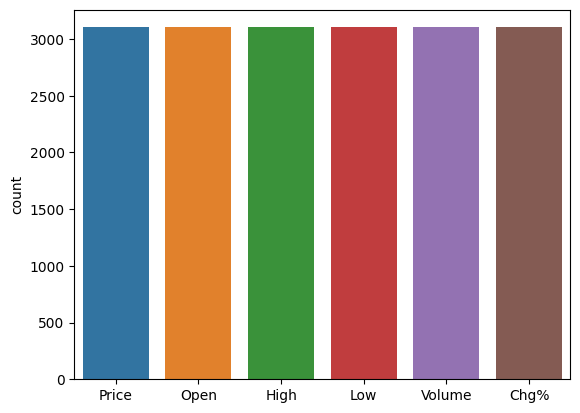

In [30]:
sns.countplot(df)      # Just to know if there are null values in any column
plt.show()       

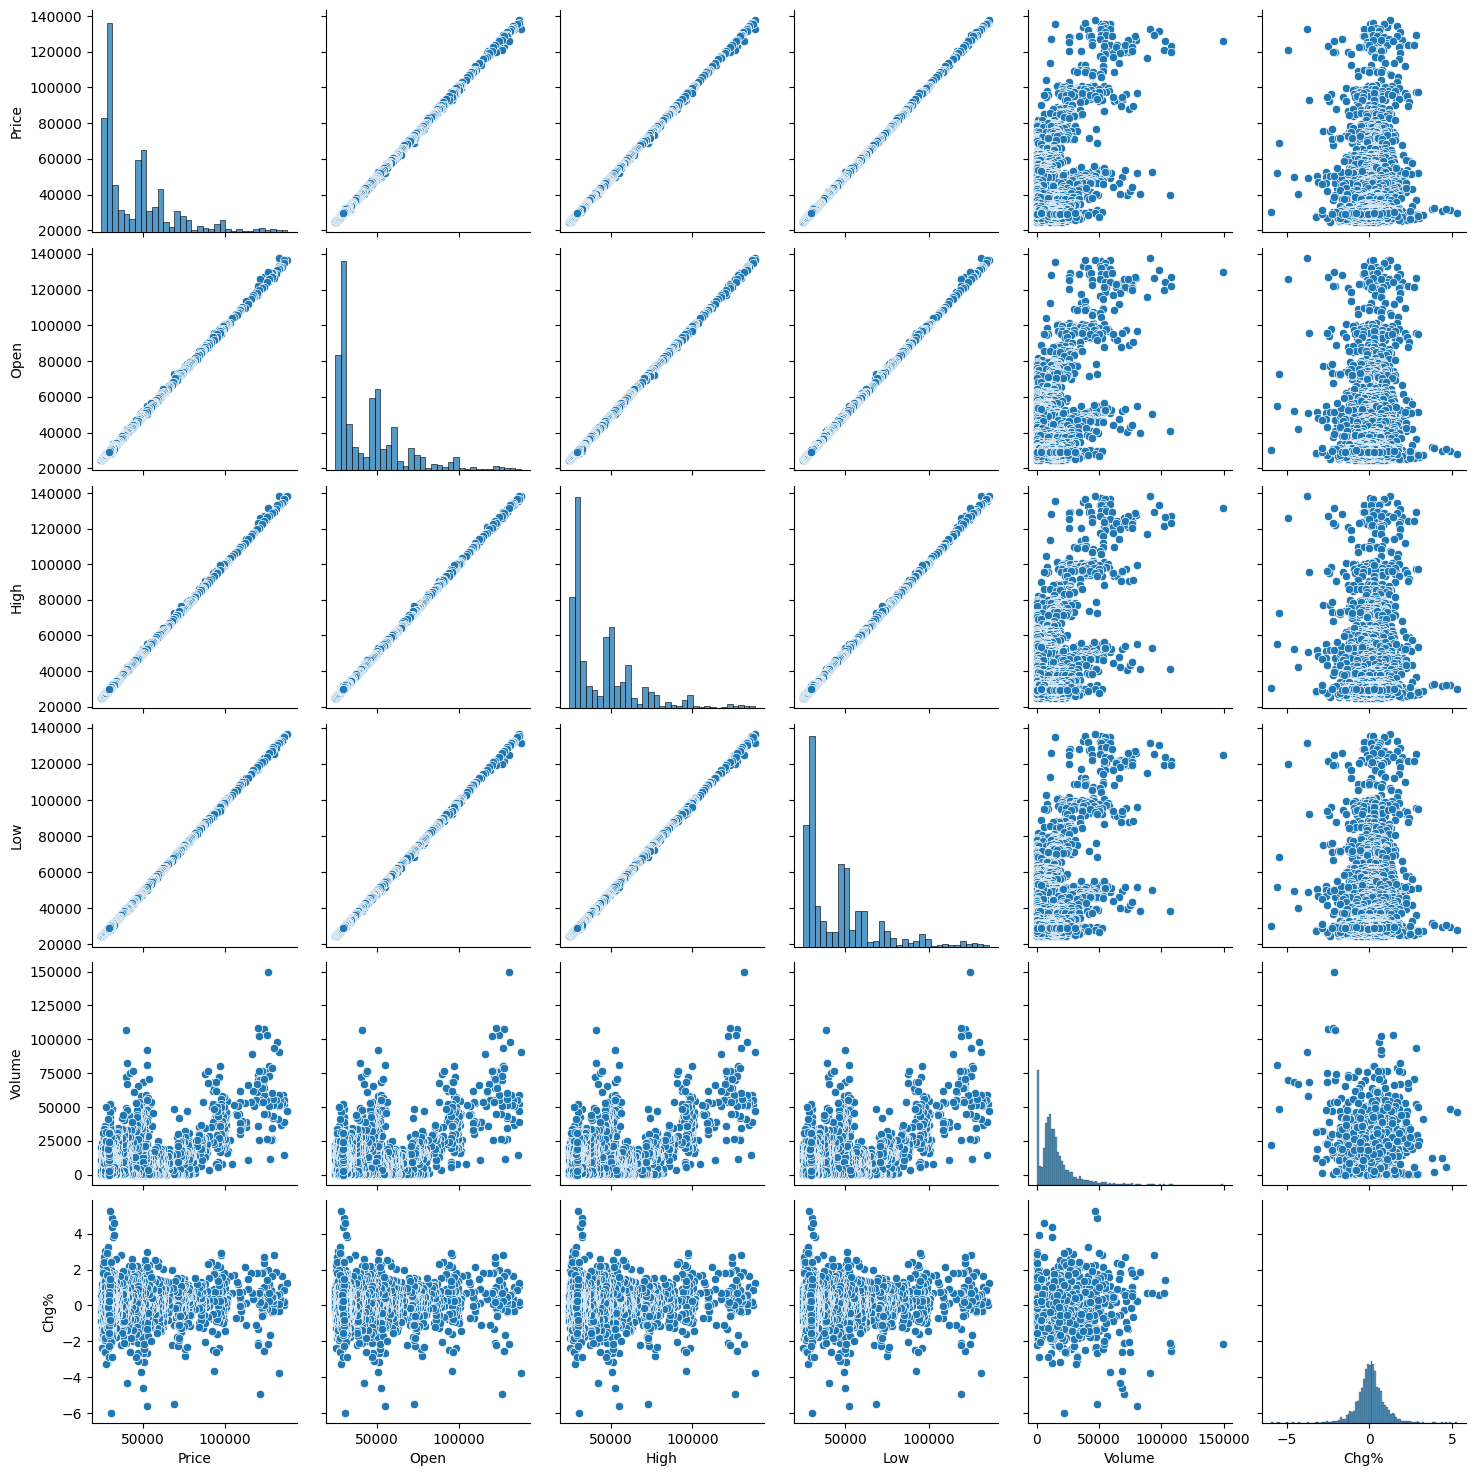

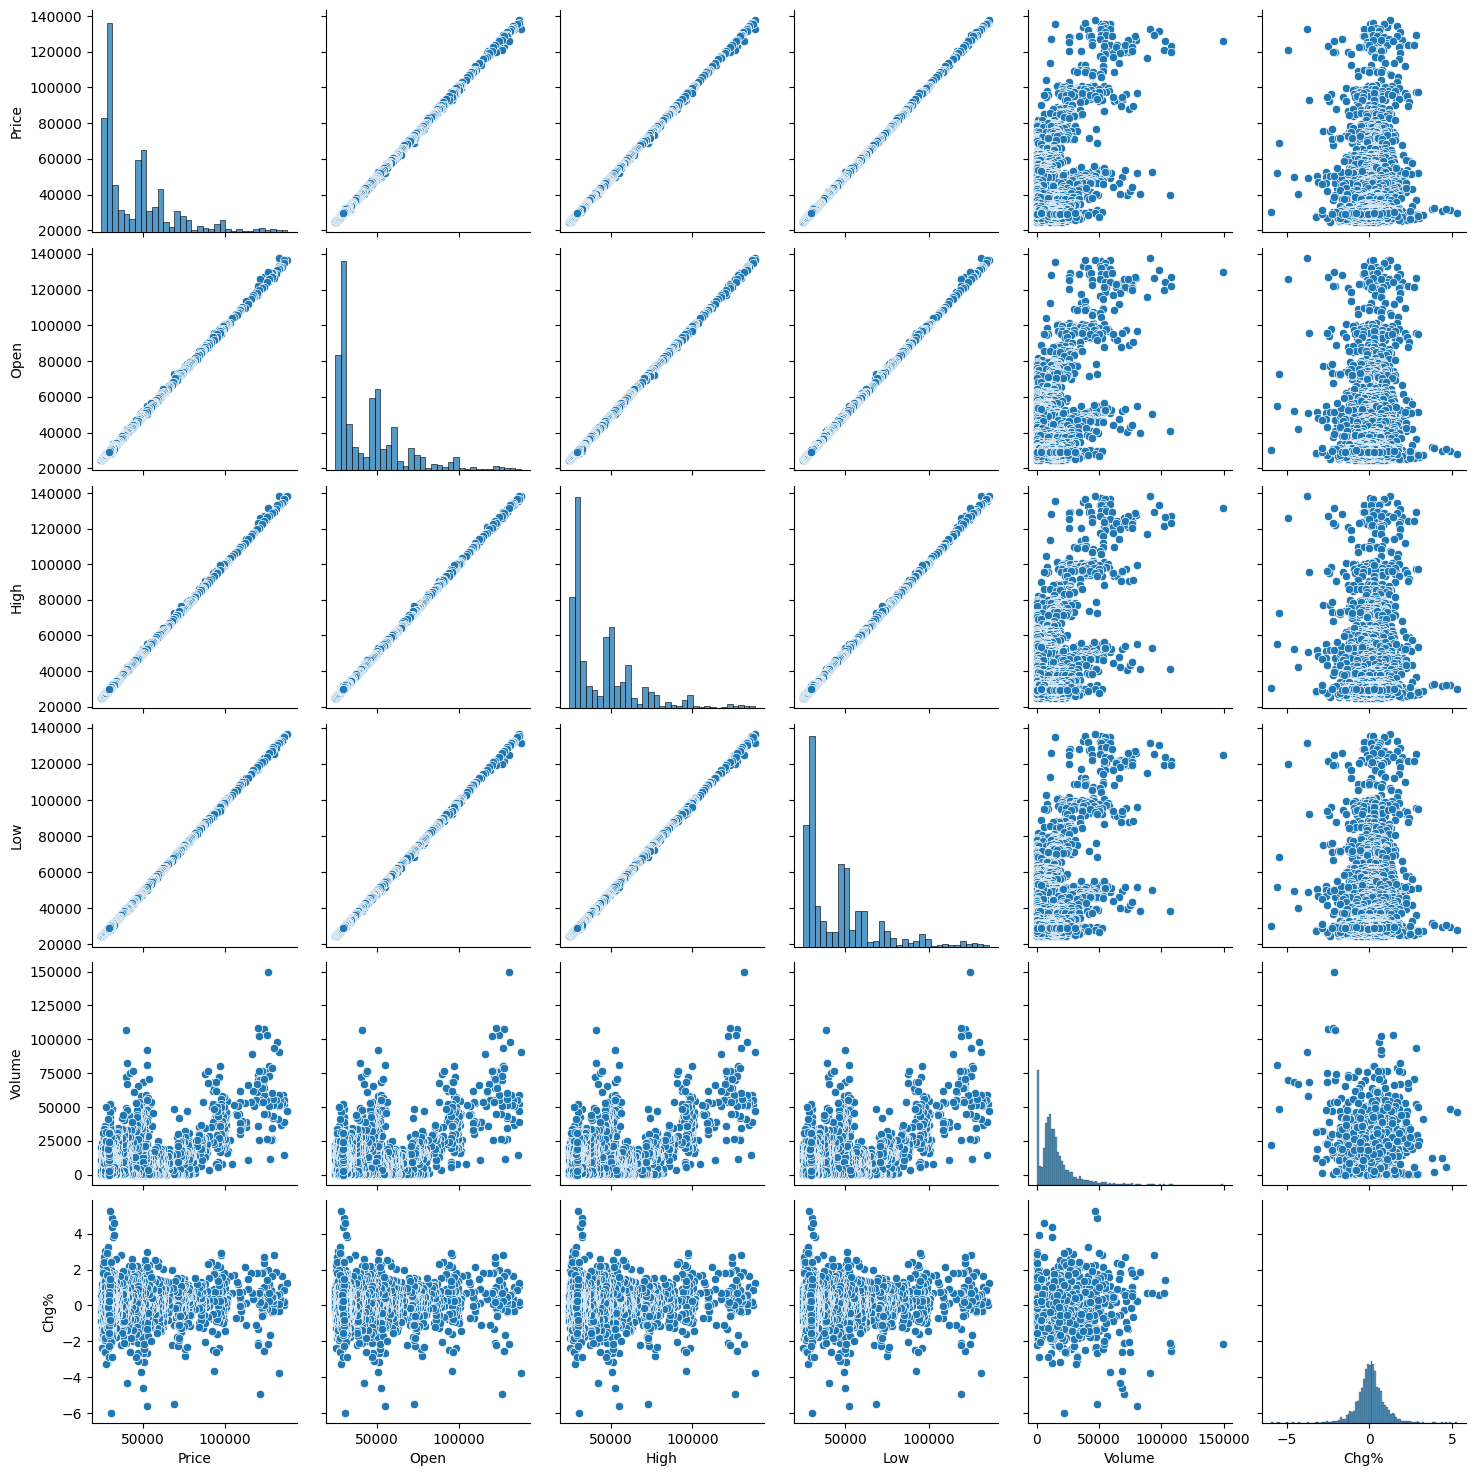

In [28]:
sns.pairplot(df2)      # Graphical representation of correlation b/w all the diffrent columns
plt.show()


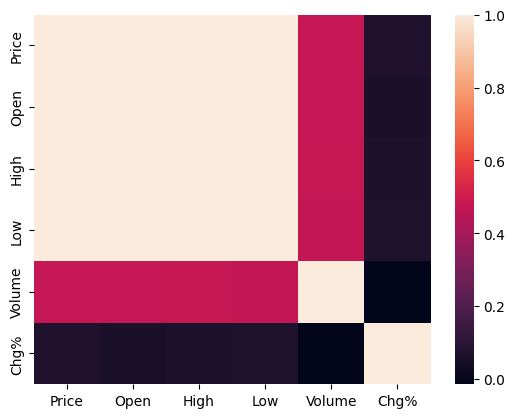

In [33]:
sns.heatmap(df2.corr())
plt.show()

**LINEAR REGRESSION MODELLING**
**(PRICE PREDICTION)**

In [36]:
X = df[['Open', 'High', 'Low', 'Volume', 'Chg%']]
y = df['Price']

In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [38]:
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size = 0.77, random_state = 100)

In [39]:
lm = LinearRegression()

In [40]:
lm.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [41]:
print(lm.intercept_)

-34.667770797714184


In [42]:
coeff_df = pd.DataFrame(lm.coef_,X.columns,columns=['Coefficient'])
coeff_df

,Coefficient
Open,-0.190341
High,0.521845
Low,0.669595
Volume,0.001555
Chg%,144.528391


In [43]:
predictions = lm.predict(X_test)

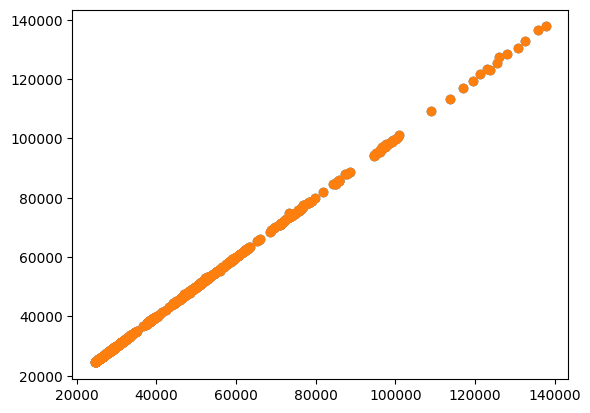

In [46]:
plt.scatter(y_test,predictions)
plt.show()

C:\Users\rezay\AppData\Local\Temp\ipykernel_6208\2979670681.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((y_test,predictions),bins = 20)


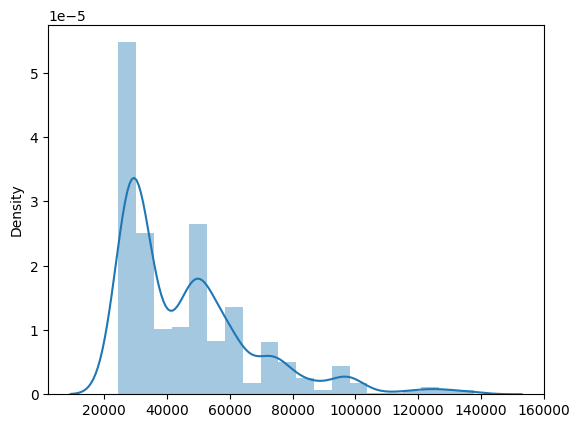

In [54]:
sns.distplot((y_test,predictions),bins = 20)
plt.show()

In [55]:
from sklearn import metrics

In [56]:
print("MAE",metrics.mean_absolute_error(y_test,predictions))
print("MSE",metrics.mean_squared_error(y_test,predictions))
print("RMSE",np.sqrt(metrics.mean_squared_error(y_test,predictions)))

MAE 95.31084045079754
MSE 25310.376284457165
RMSE 159.09235143292454


In [68]:
mean_price = df["Price"].mean()
RMSE = np.sqrt(metrics.mean_squared_error(y_test,predictions))
RMSE/mean_price
df["Target"] = df["Price"].shift(-1)

In [71]:
df = df.dropna()

**LOGISTICS REGRESSION MODELLING ON THE SAME DATASET**

In [73]:
df["Target"] = (df["Price"].shift(-1) > df["Price"]).astype(int)

C:\Users\rezay\AppData\Local\Temp\ipykernel_6208\2445265102.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Target"] = (df["Price"].shift(-1) > df["Price"]).astype(int)


In [76]:
df.head(10)

,Date,Price,Open,High,Low,Volume,Chg%,Target
0,2026-01-02,135793,136143,137037,135525,51877,0.02,0
1,2026-01-01,135771,135687,135850,135001,14622,0.23,0
2,2025-12-31,135454,136526,136527,134866,59050,1.10,0
3,2025-12-30,133974,133185,134880,132853,36733,1.04,0
4,2025-12-29,132595,137628,138269,131695,90640,-3.77,1
5,2025-12-26,137789,136300,138300,136300,46771,1.24,0
6,2025-12-24,136104,136309,136500,135281,38763,0.22,0
7,2025-12-23,135799,134900,136888,134698,54815,0.86,0
8,2025-12-22,134638,132600,134688,132600,52738,1.67,0
9,2025-12-19,132427,132252,132575,131803,41184,-0.19,1


In [80]:
pd.DataFrame(df[df["Target"]== 1])    # These are the days where our next day prediction will high as compare to current day price 

,Date,Price,Open,High,Low,Volume,Chg%,Target
4,2025-12-29,132595,137628,138269,131695,90640,-3.77,1
9,2025-12-19,132427,132252,132575,131803,41184,-0.19,1
10,2025-12-18,132684,133117,133629,132090,50581,-0.32,1
16,2025-12-10,128500,129160,129163,128259,26343,-0.27,1
18,2025-12-08,128736,128900,129542,128301,34061,-0.36,1
...,...,...,...,...,...,...,...,...
3097,2014-01-08,28934,28916,29029,28820,18140,-0.09,1
3098,2014-01-07,28959,29130,29195,28912,18710,-0.55,1
3099,2014-01-06,29119,29300,29395,29051,24380,-0.55,1
3100,2014-01-04,29279,29279,29279,29279,0,-1.51,1


In [83]:
pd.DataFrame(df[df["Target"]==0])  # These will be the days where the predicted price shall be low as compare to the current day price

,Date,Price,Open,High,Low,Volume,Chg%,Target
0,2026-01-02,135793,136143,137037,135525,51877,0.02,0
1,2026-01-01,135771,135687,135850,135001,14622,0.23,0
2,2025-12-31,135454,136526,136527,134866,59050,1.10,0
3,2025-12-30,133974,133185,134880,132853,36733,1.04,0
5,2025-12-26,137789,136300,138300,136300,46771,1.24,0
...,...,...,...,...,...,...,...,...
3091,2014-01-16,29168,29165,29250,29090,12580,0.06,0
3094,2014-01-13,29312,29170,29330,29133,13780,0.49,0
3095,2014-01-10,29169,29030,29198,28960,15810,0.59,0
3096,2014-01-09,28997,28990,29053,28865,15130,0.22,0


In [87]:
X = df[['Price', 'Open', 'High', 'Low', 'Volume', 'Chg%']]
y = df['Target']

In [88]:
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size = 0.7,random_state = 101)

In [90]:
from sklearn.linear_model import LogisticRegression

In [91]:
lr = LogisticRegression()

In [92]:
lr.fit(X_train,y_train)

C:\Users\rezay\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [95]:
predictions = lr.predict(X_test)

In [100]:
from sklearn.metrics import classification_report

In [102]:
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.84      0.87      0.86       491
           1       0.85      0.82      0.83       440

    accuracy                           0.85       931
   macro avg       0.85      0.84      0.85       931
weighted avg       0.85      0.85      0.85       931

